In [65]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 설치/네트워크 점검
# ─────────────────────────────────────────────
# 처음이라면 아래 주석을 해제해 설치하세요. (bs4 = BeautifulSoup)
# !pip install requests beautifulsoup4 pandas -q

import platform
import warnings
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")
np.random.seed(42)

# 핵심 도구 1: BeautifulSoup — HTML을 파싱(parsing, 구조 분석)하는 라이브러리
from bs4 import BeautifulSoup

# 핵심 도구 2: requests — 웹에 요청을 보내는 라이브러리 (없을 수도 있으니 안전하게 점검)
try:
    import requests
    HAS_REQUESTS = True
except Exception:
    HAS_REQUESTS = False

print("준비 완료!")
print("BeautifulSoup: 사용 가능 (핵심 학습은 이 도구로 진행)")
print("requests     :", "사용 가능" if HAS_REQUESTS else "없음 → 네트워크 셀은 로컬 폴백으로 대체됩니다")

준비 완료!
BeautifulSoup: 사용 가능 (핵심 학습은 이 도구로 진행)
requests     : 사용 가능


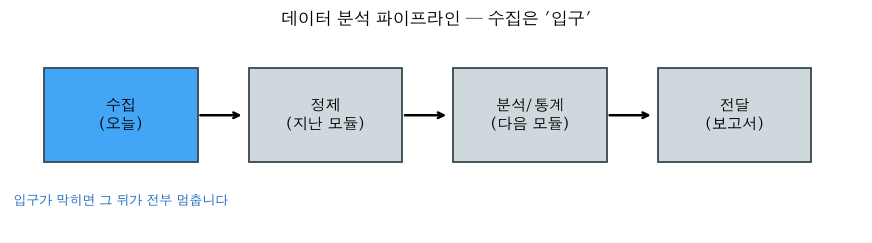

In [66]:
# ─────────────────────────────────────────────
# [도식] 데이터 분석 파이프라인에서 '수집'의 위치
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(11, 2.6))
ax.axis("off")
steps = [("수집\n(오늘)", "#42a5f5"), ("정제\n(지난 모듈)", "#cfd8dc"),
         ("분석/통계\n(다음 모듈)", "#cfd8dc"), ("전달\n(보고서)", "#cfd8dc")]
for i, (label, color) in enumerate(steps):
    x = 0.04 + i * 0.24
    ax.add_patch(plt.Rectangle((x, 0.3), 0.18, 0.4, facecolor=color, edgecolor="#37474f", lw=1.3))
    ax.text(x + 0.09, 0.5, label, ha="center", va="center", fontsize=11)
    if i < 3:
        ax.annotate("", xy=(x + 0.235, 0.5), xytext=(x + 0.18, 0.5),
                    arrowprops=dict(arrowstyle="->", lw=1.8))
ax.text(0.13, 0.12, "입구가 막히면 그 뒤가 전부 멈춥니다", ha="center", fontsize=9, color="#1565c0")
ax.set_xlim(0, 1); ax.set_ylim(0, 0.85)
plt.title("데이터 분석 파이프라인 — 수집은 '입구'", fontsize=12)
plt.show()

In [67]:
# [네트워크 필요] — 연결이 안 되면 자동으로 로컬 폴백으로 같은 구조를 학습합니다.
# 연습 전용 사이트 httpbin.org 에 GET 요청을 보내, 응답 구조를 살펴봅니다.
url = "https://httpbin.org/get"
headers = {"User-Agent": "modulabs-edu-bot/1.0 (학습용)"}  # 내가 누구인지 예의 있게 밝힙니다.

try:
    if not HAS_REQUESTS:
        raise RuntimeError("requests 미설치")
    resp = requests.get(url, headers=headers, timeout=5)
    status = resp.status_code
    ctype = resp.headers.get("Content-Type", "?")
    source = "실제 네트워크 응답"
except Exception as e:
    # 로컬 폴백: 미리 저장해 둔 응답 구조로 동일하게 학습합니다.
    status = 200
    ctype = "application/json"
    source = f"로컬 폴백 (네트워크 불가: {type(e).__name__})"

print("출처     :", source)
print("상태 코드 :", status, "→", "성공(2xx)" if 200 <= status < 300 else "확인 필요")
print("Content-Type:", ctype, "  ← 응답 본문이 어떤 형식인지 알려줍니다")
print("\n해석: 200이면 서버가 요청을 정상 처리한 것입니다. 이제 응답 본문(body)에서 데이터를 꺼내면 됩니다.")

출처     : 로컬 폴백 (네트워크 불가: UnicodeEncodeError)
상태 코드 : 200 → 성공(2xx)
Content-Type: application/json   ← 응답 본문이 어떤 형식인지 알려줍니다

해석: 200이면 서버가 요청을 정상 처리한 것입니다. 이제 응답 본문(body)에서 데이터를 꺼내면 됩니다.


In [68]:
status_meaning = {
    200: "성공 — 잘 받았다",
    404: "없는 페이지",
    403: "접근 금지 — 차단당함",
    500: "서버 내부 오류",
}

def describe_status(code):
    meaning = status_meaning.get(code, "알 수 없는 상태코드")
    if 200 <= code < 300:
        result = "성공"
    else:
        result = "실패/확인 필요"
    print(f"{code}: {meaning} → {result}")

describe_status(200)
describe_status(404)
describe_status(403)

200: 성공 — 잘 받았다 → 성공
404: 없는 페이지 → 실패/확인 필요
403: 접근 금지 — 차단당함 → 실패/확인 필요


In [69]:
headers = {"User-Agent": "modulabs-edu-bot/1.0"}  # 한글 제거

In [70]:
url = "https://httpbin.org/get"
headers = {"User-Agent": "modulabs-edu-bot/1.0"}  # 한글 제거

try:
    resp = requests.get(url, headers=headers, timeout=5)
    status = resp.status_code
    ctype = resp.headers.get("Content-Type", "?")
    source = "실제 네트워크 응답"
except Exception as e:
    status = 200
    ctype = "application/json"
    source = f"로컬 폴백 (네트워크 불가: {type(e).__name__})"

print("출처     :", source)
print("상태 코드 :", status)
print("Content-Type:", ctype)


출처     : 실제 네트워크 응답
상태 코드 : 200
Content-Type: application/json


In [71]:
# 예제: '정적' HTML — 데이터가 소스 안에 그대로 들어 있습니다.
html_static = '''
<html><body>
  <div id="product-list">
    <div class="product-card"><span class="name">무선 이어폰</span><span class="price">89,900원</span></div>
    <div class="product-card"><span class="name">코튼 셔츠</span><span class="price">29,900원</span></div>
  </div>
</body></html>
'''

soup_static = BeautifulSoup(html_static, "html.parser")
names = [tag.get_text() for tag in soup_static.select(".product-card .name")]
print("정적 페이지에서 추출한 상품명:", names)
print("→ 데이터가 소스에 있으니 BeautifulSoup으로 바로 추출됩니다.")

정적 페이지에서 추출한 상품명: ['무선 이어폰', '코튼 셔츠']
→ 데이터가 소스에 있으니 BeautifulSoup으로 바로 추출됩니다.


In [72]:
# 예제: '동적' HTML — 데이터가 <script> 안에만 있고, 화면용 영역은 비어 있습니다.
# 실제 브라우저라면 JavaScript가 이 데이터를 #app 안에 그려넣지만,
# requests/BeautifulSoup은 JS를 실행하지 않으므로 '빈 뼈대'만 봅니다.
html_dynamic = '''
<html><body>
  <div id="app"><!-- 상품이 여기에 표시됩니다 (JavaScript가 채웁니다) --></div>
  <script>
    const products = [
      {name: "노트북", price: 1290000},
      {name: "키보드", price: 49000}
    ];
    // 브라우저에서는 위 데이터를 #app 안에 렌더링(rendering)합니다.
  </script>
</body></html>
'''

soup_dynamic = BeautifulSoup(html_dynamic, "html.parser")
app_content = soup_dynamic.select_one("#app").get_text(strip=True)
cards = soup_dynamic.select(".product-card")

print("#app 영역의 내용:", repr(app_content), "  ← 비어 있습니다!")
print("찾은 상품 카드 수:", len(cards), "개  ← 0개! 데이터가 화면용 HTML에 없습니다.")
print("\n해석: 화면엔 노트북·키보드가 보이겠지만, requests가 받는 소스엔 데이터가 없습니다.")
print("→ 이런 동적 페이지는 BeautifulSoup만으론 못 긁습니다. (다음 시간 Playwright의 등장 이유)")

#app 영역의 내용: ''   ← 비어 있습니다!
찾은 상품 카드 수: 0 개  ← 0개! 데이터가 화면용 HTML에 없습니다.

해석: 화면엔 노트북·키보드가 보이겠지만, requests가 받는 소스엔 데이터가 없습니다.
→ 이런 동적 페이지는 BeautifulSoup만으론 못 긁습니다. (다음 시간 Playwright의 등장 이유)


In [73]:
# 예제: 작은 HTML을 파싱해 선택자로 값 꺼내기
html_mini = '''
<div id="product-list">
  <div class="product-card" data-pid="P001">
    <h3 class="name">무선 이어폰</h3>
    <a class="link" href="/products/P001">상세보기</a>
    <span class="price">89,900원</span>
  </div>
</div>
'''
soup = BeautifulSoup(html_mini, "html.parser")

# 1) select_one — 맞는 첫 번째 하나
name = soup.select_one(".name").get_text()
print("상품명(.name):", name)

# 2) 속성값 꺼내기 — href, data-pid
link = soup.select_one("a.link")
print("링크(href)   :", link.get("href"))
print("상품ID(data-pid):", soup.select_one(".product-card").get("data-pid"))

상품명(.name): 무선 이어폰
링크(href)   : /products/P001
상품ID(data-pid): P001


In [74]:
# 예제: find_all vs select, 그리고 자주 나는 오류 읽는 법
html_two = '''
<ul><li class="item">사과</li><li class="item">바나나</li><li class="item">체리</li></ul>
'''
soup2 = BeautifulSoup(html_two, "html.parser")

# 모두 꺼내기 — select(여럿)는 항상 '리스트'를 돌려줍니다.
items = soup2.select("li.item")
print("찾은 개수:", len(items))
print("값들:", [i.get_text() for i in items])

# 흔한 오류: 없는 선택자를 select_one 하면 None이 나오고, None에 .get_text()를 부르면 에러납니다.
ghost = soup2.select_one(".not-exist")
print("\n없는 선택자 결과:", ghost, "  ← None 입니다")
if ghost is None:
    print("→ None일 때 .get_text()를 부르면 AttributeError가 납니다. 항상 None인지 먼저 확인하세요.")

찾은 개수: 3
값들: ['사과', '바나나', '체리']

없는 선택자 결과: None   ← None 입니다
→ None일 때 .get_text()를 부르면 AttributeError가 납니다. 항상 None인지 먼저 확인하세요.


In [75]:
soup = BeautifulSoup(html_mini, "html.parser")

# 1) 가격 텍스트를 꺼내 출력해 보세요.
price = soup.select_one(".price").get_text()
print("가격:", price)

# 2) 상세보기 링크의 href를 꺼내 출력해 보세요.
href = soup.select_one("a.link").get_text()  # 이건 텍스트고
href = soup.select_one("a.link").get("href")  # href는 속성값이니까 이렇게
print("상세보기 링크:", href)

가격: 89,900원
상세보기 링크: /products/P001


In [76]:
# ─────────────────────────────────────────────
# 모두마켓 상품 목록 페이지 (노트북 내장 HTML — 인터넷 불필요, 항상 실행됩니다)
# 실제 현장처럼 '오염'을 일부러 심어 둡니다: 가격에 공백/통화기호 혼재, 일부 값 결측.
# ─────────────────────────────────────────────
modumarket_html = '''
<html><head><title>모두마켓 - 상품 목록</title></head>
<body>
  <h1>오늘의 추천 상품</h1>
  <div id="product-list">
    <div class="product-card" data-pid="P001">
      <h3 class="name">무선 이어폰</h3>
      <span class="category">가전</span>
      <span class="price">89,900원</span>
      <span class="rating">4.5</span>
    </div>
    <div class="product-card" data-pid="P002">
      <h3 class="name">코튼 셔츠</h3>
      <span class="category">패션</span>
      <span class="price"> 29,900 원 </span>
      <span class="rating">4.2</span>
    </div>
    <div class="product-card" data-pid="P003">
      <h3 class="name">수분 크림</h3>
      <span class="category"> 뷰티 </span>
      <span class="price">19,900원</span>
      <span class="rating">4.7</span>
    </div>
    <div class="product-card" data-pid="P004">
      <h3 class="name">유기농 견과 세트</h3>
      <span class="category">식품</span>
      <span class="price"></span>
      <span class="rating">4.0</span>
    </div>
    <div class="product-card" data-pid="P005">
      <h3 class="name">베스트셀러 도서</h3>
      <span class="category">도서</span>
      <span class="price">12,000원</span>
      <span class="rating"></span>
    </div>
    <div class="product-card" data-pid="P006">
      <h3 class="name">블루투스 스피커</h3>
      <span class="category">가전</span>
      <span class="price">₩129,900</span>
      <span class="rating">4.3</span>
    </div>
  </div>
</body></html>
'''
soup = BeautifulSoup(modumarket_html, "html.parser")

print("페이지 제목:", soup.select_one("title").get_text())
cards = soup.select(".product-card")
print("발견한 상품 카드 수:", len(cards), "개")

페이지 제목: 모두마켓 - 상품 목록
발견한 상품 카드 수: 6 개


In [77]:
# 예제: 모든 상품을 한 번에 추출 — '바깥에서 카드 모으고, 안에서 값 꺼내기'
products_raw = []
for card in cards:                                   # 1) 카드 하나씩 돌며
    pid = card.get("data-pid")                        #    속성에서 상품ID
    name = card.select_one(".name").get_text()        #    카드 안에서 이름
    category = card.select_one(".category").get_text()
    price = card.select_one(".price").get_text()      #    (지저분한 채로 일단 그대로)
    rating = card.select_one(".rating").get_text()
    products_raw.append({                             # 2) 딕셔너리로 모으기
        "product_id": pid, "name": name,
        "category": category, "price": price, "rating": rating,
    })

print(f"추출한 상품 {len(products_raw)}개. 앞 3개를 봅니다 (아직 '날것' 상태):")
for row in products_raw[:3]:
    print(row)

추출한 상품 6개. 앞 3개를 봅니다 (아직 '날것' 상태):
{'product_id': 'P001', 'name': '무선 이어폰', 'category': '가전', 'price': '89,900원', 'rating': '4.5'}
{'product_id': 'P002', 'name': '코튼 셔츠', 'category': '패션', 'price': ' 29,900 원 ', 'rating': '4.2'}
{'product_id': 'P003', 'name': '수분 크림', 'category': ' 뷰티 ', 'price': '19,900원', 'rating': '4.7'}


In [78]:
for row in products_raw:
    print(row)

{'product_id': 'P001', 'name': '무선 이어폰', 'category': '가전', 'price': '89,900원', 'rating': '4.5'}
{'product_id': 'P002', 'name': '코튼 셔츠', 'category': '패션', 'price': ' 29,900 원 ', 'rating': '4.2'}
{'product_id': 'P003', 'name': '수분 크림', 'category': ' 뷰티 ', 'price': '19,900원', 'rating': '4.7'}
{'product_id': 'P004', 'name': '유기농 견과 세트', 'category': '식품', 'price': '', 'rating': '4.0'}
{'product_id': 'P005', 'name': '베스트셀러 도서', 'category': '도서', 'price': '12,000원', 'rating': ''}
{'product_id': 'P006', 'name': '블루투스 스피커', 'category': '가전', 'price': '₩129,900', 'rating': '4.3'}


In [79]:
high_rated = []
for p in products_raw:
    r = p["rating"]
    if r != "" and float(r) >= 4.5:
        high_rated.append(p["name"])

print(high_rated)

['무선 이어폰', '수분 크림']


In [80]:
# 1단계) 딕셔너리 리스트 → DataFrame
df = pd.DataFrame(products_raw)
print("수집 결과를 DataFrame으로:", df.shape)
display(df)

수집 결과를 DataFrame으로: (6, 5)


,product_id,name,category,price,rating
0,P001,무선 이어폰,가전,"89,900원",4.5
1,P002,코튼 셔츠,패션,"29,900 원",4.2
2,P003,수분 크림,뷰티,"19,900원",4.7
3,P004,유기농 견과 세트,식품,,4.0
4,P005,베스트셀러 도서,도서,"12,000원",
5,P006,블루투스 스피커,가전,"₩129,900",4.3


In [81]:
# 2단계) 문자열 정제 — 가격에서 '숫자만' 남기기
# 정규표현식으로 숫자(0-9)가 아닌 모든 문자(원, ₩, 쉼표, 공백)를 제거합니다.
df["price_clean"] = (
    df["price"]
    .str.replace(r"[^0-9]", "", regex=True)   # 숫자 외 전부 제거
    .replace("", np.nan)                       # 빈 문자열은 결측(NaN)으로
)

# 카테고리의 앞뒤 공백도 제거 (지난 모듈의 .str.strip())
df["category"] = df["category"].str.strip()

print("가격 정제 전후 비교:")
display(df[["name", "price", "price_clean", "category"]])

가격 정제 전후 비교:


,name,price,price_clean,category
0,무선 이어폰,"89,900원",89900,가전
1,코튼 셔츠,"29,900 원",29900,패션
2,수분 크림,"19,900원",19900,뷰티
3,유기농 견과 세트,,NaN,식품
4,베스트셀러 도서,"12,000원",12000,도서
5,블루투스 스피커,"₩129,900",129900,가전


In [82]:
# 3단계) 타입 변환 + 결측 처리
# 문자 → 숫자로 변환 (결측은 NaN 유지)
df["price_clean"] = pd.to_numeric(df["price_clean"])
df["rating"] = pd.to_numeric(df["rating"].str.strip().replace("", np.nan))

print("자료형 확인 — price_clean이 숫자가 되었나?")
print(df[["price_clean", "rating"]].dtypes)

# 결측 진단 (지난 모듈의 습관: 먼저 얼마나 비었는지 본다)
print("\n[결측 진단]")
print(df[["price_clean", "rating"]].isna().sum())

# 비즈니스 판단: 가격 결측은 '집계에서 제외', 별점 결측은 '평균으로 대체'한다고 결정
df_priced = df.dropna(subset=["price_clean"]).copy()        # 가격 없는 상품은 매출 집계서 제외
df["rating"] = df["rating"].fillna(df["rating"].mean().round(1))  # 별점은 평균 대체

print("\n→ 판단 기록: 가격 결측 1건은 집계 제외, 별점 결측 1건은 평균으로 대체했다.")

자료형 확인 — price_clean이 숫자가 되었나?
price_clean    float64
rating         float64
dtype: object

[결측 진단]
price_clean    1
rating         1
dtype: int64

→ 판단 기록: 가격 결측 1건은 집계 제외, 별점 결측 1건은 평균으로 대체했다.


In [83]:
# 최종) 모두마켓 'products' 스키마로 정리 — 다음 모듈로 넘길 분석용 표
products_final = df[["product_id", "category", "price_clean", "rating", "name"]].rename(
    columns={"price_clean": "price"}
)
print("=== 분석 가능한 최종 products 표 ===")
display(products_final)

# 이제 집계가 됩니다! 카테고리별 평균 가격 — 수집한 데이터로 첫 분석
print("\n[카테고리별 평균 가격] — 수집 → 정제 → 분석이 이어졌습니다")
print(products_final.dropna(subset=["price"]).groupby("category")["price"].mean().round(0))

=== 분석 가능한 최종 products 표 ===


,product_id,category,price,rating,name
0,P001,가전,89900.0,4.5,무선 이어폰
1,P002,패션,29900.0,4.2,코튼 셔츠
2,P003,뷰티,19900.0,4.7,수분 크림
3,P004,식품,NaN,4.0,유기농 견과 세트
4,P005,도서,12000.0,4.3,베스트셀러 도서
5,P006,가전,129900.0,4.3,블루투스 스피커



[카테고리별 평균 가격] — 수집 → 정제 → 분석이 이어졌습니다
category
가전    109900.0
도서     12000.0
뷰티     19900.0
패션     29900.0
Name: price, dtype: float64


In [84]:
top3 = products_final.dropna(subset=["price"]).sort_values("price", ascending=False).head(3)
print(top3)

  product_id category     price  rating      name
5       P006       가전  129900.0     4.3  블루투스 스피커
0       P001       가전   89900.0     4.5    무선 이어폰
1       P002       패션   29900.0     4.2     코튼 셔츠


In [85]:
# [AI 보조 코딩 — ③ 검증 시연]
# AI가 아래 코드를 줬다고 가정합니다. 그런데 선택자가 '.product'로 되어 있습니다.
# (실제 HTML의 클래스는 '.product-card'인데, AI가 흔히 비슷한 이름으로 틀립니다.)
ai_generated = []
for card in soup.select(".product"):          # ← AI가 준 셀렉터 (틀렸을 수 있음!)
    ai_generated.append(card.select_one(".name").get_text())

# ★ 검증: 결과 개수를 '내가 아는 사실'과 대조합니다.
print("AI 코드가 추출한 상품 수:", len(ai_generated))
print("내가 페이지에서 확인한 실제 상품 수:", len(soup.select(".product-card")))
if len(ai_generated) == 0:
    print("→ ⚠ 0개! 에러는 안 났지만 결과가 비었습니다. 선택자가 틀렸다는 신호입니다.")
    print("   (이런 '조용한 실패'를 잡으려면 반드시 개수를 검증해야 합니다.)")

AI 코드가 추출한 상품 수: 0
내가 페이지에서 확인한 실제 상품 수: 6
→ ⚠ 0개! 에러는 안 났지만 결과가 비었습니다. 선택자가 틀렸다는 신호입니다.
   (이런 '조용한 실패'를 잡으려면 반드시 개수를 검증해야 합니다.)


In [86]:
# [AI 보조 코딩 — ④ 수정]
# 검증에서 '0개'를 발견했으니, 실제 HTML을 보고 선택자를 '.product-card'로 고칩니다.
fixed = []
for card in soup.select(".product-card"):     # ← 사람이 검증 후 수정한 셀렉터
    fixed.append(card.select_one(".name").get_text())

print("수정 후 추출한 상품 수:", len(fixed))
print("상품명:", fixed)
print("\n→ 검증(개수 대조) → 수정(올바른 셀렉터)으로 신뢰할 수 있는 코드가 되었습니다.")
print("   AI는 속도를 줬고, 판단·검증은 사람이 했습니다.")

수정 후 추출한 상품 수: 6
상품명: ['무선 이어폰', '코튼 셔츠', '수분 크림', '유기농 견과 세트', '베스트셀러 도서', '블루투스 스피커']

→ 검증(개수 대조) → 수정(올바른 셀렉터)으로 신뢰할 수 있는 코드가 되었습니다.
   AI는 속도를 줬고, 판단·검증은 사람이 했습니다.


In [87]:
def verify_count(selector, expected):
    found = len(soup.select(selector))
    if found == expected:
        print(f"✅ '{selector}': {found}개 (예상 {expected}개) — 통과")
    else:
        print(f"⚠ '{selector}': {found}개 (예상 {expected}개) — 불일치! 선택자 확인 필요")

verify_count(".product-card", 6)   # 통과해야 함
verify_count(".product", 6)        # 불일치(0개)가 나와야 함

✅ '.product-card': 6개 (예상 6개) — 통과
⚠ '.product': 0개 (예상 6개) — 불일치! 선택자 확인 필요


In [88]:
# robots.txt 확인 — 파이썬 표준 라이브러리 urllib.robotparser
# 핵심 학습은 '규칙 해석'이므로, 규칙 내용을 직접 넣어 항상 실행되게 합니다.
from urllib.robotparser import RobotFileParser

# 예시 robots.txt 규칙 (실제 사이트들이 이런 형식을 씁니다)
robots_text = '''
User-agent: *
Disallow: /private/
Disallow: /admin/
Allow: /
Crawl-delay: 2
'''

rp = RobotFileParser()
rp.parse(robots_text.strip().splitlines())

ua = "modulabs-edu-bot"
print("이 경로를 긁어도 될까? (robots.txt 기준)")
print("  /catalogue/page-1.html :", rp.can_fetch(ua, "/catalogue/page-1.html"))  # 허용
print("  /private/secret.html   :", rp.can_fetch(ua, "/private/secret.html"))    # 금지
print("\n→ Disallow 경로는 False가 나옵니다. 코드를 짜기 전에 이렇게 먼저 확인하는 습관!")

이 경로를 긁어도 될까? (robots.txt 기준)
  /catalogue/page-1.html : True
  /private/secret.html   : False

→ Disallow 경로는 False가 나옵니다. 코드를 짜기 전에 이렇게 먼저 확인하는 습관!


In [89]:
# [네트워크 필요] — 실제 사이트의 robots.txt도 같은 방식으로 읽습니다. (안 되면 위 학습으로 충분)
real_rp = RobotFileParser()
try:
    if not HAS_REQUESTS:
        raise RuntimeError("requests 미설치")
    real_rp.set_url("https://books.toscrape.com/robots.txt")
    real_rp.read()
    allowed = real_rp.can_fetch("*", "https://books.toscrape.com/catalogue/page-1.html")
    print("실제 books.toscrape.com 에서 /catalogue/page-1.html 수집 허용?:", allowed)
except Exception as e:
    print(f"네트워크 불가({type(e).__name__}) — 위 셀의 규칙 해석 학습으로 대체합니다.")
    print("실무에서는 '사이트주소/robots.txt'를 브라우저로 직접 열어 봐도 됩니다.")

실제 books.toscrape.com 에서 /catalogue/page-1.html 수집 허용?: True


In [90]:
# 요청 예의 — 여러 페이지를 긁을 때는 요청 사이에 '쉬어 줍니다'
import time

pages = ["page-1", "page-2", "page-3"]
print("요청 예의를 지키며 순회 (각 요청 사이 1초 대기):")
for p in pages:
    # 실제로는 여기서 requests.get(...) 을 호출합니다. 지금은 예의 패턴만 시연.
    print(f"  요청 → {p}  (서버 부담을 줄이기 위해 잠시 대기)")
    time.sleep(1)   # rate limiting: 서버에 한꺼번에 몰리지 않도록
print("완료. time.sleep()으로 서버에 부담을 주지 않는 것이 기본 예의입니다.")

요청 예의를 지키며 순회 (각 요청 사이 1초 대기):
  요청 → page-1  (서버 부담을 줄이기 위해 잠시 대기)
  요청 → page-2  (서버 부담을 줄이기 위해 잠시 대기)
  요청 → page-3  (서버 부담을 줄이기 위해 잠시 대기)
완료. time.sleep()으로 서버에 부담을 주지 않는 것이 기본 예의입니다.


In [91]:
robots_text_new = '''
User-agent: *
Disallow: /private/
Disallow: /admin/
Disallow: /search
Allow: /
Crawl-delay: 2
'''

rp2 = RobotFileParser()
rp2.parse(robots_text_new.strip().splitlines())

ua = "modulabs-edu-bot"
result = rp2.can_fetch(ua, "/search?q=shoes")
print("이 경로를 긁어도 될까?")
print("  /search?q=shoes :", result)

이 경로를 긁어도 될까?
  /search?q=shoes : False


In [92]:
cards = soup.select(".item")
print("[검증] 추출 대상 카드 수:", len(cards), "개")

[검증] 추출 대상 카드 수: 0 개


In [93]:
# robots.txt 확인 — 파이썬 표준 라이브러리 urllib.robotparser
# 핵심 학습은 '규칙 해석'이므로, 규칙 내용을 직접 넣어 항상 실행되게 합니다.
from urllib.robotparser import RobotFileParser

# 예시 robots.txt 규칙 (실제 사이트들이 이런 형식을 씁니다)
robots_text = '''
User-agent: *
Disallow: /private/
Disallow: /admin/
Allow: /
Crawl-delay: 2
'''

rp = RobotFileParser()
rp.parse(robots_text.strip().splitlines())

ua = "modulabs-edu-bot"
print("이 경로를 긁어도 될까? (robots.txt 기준)")
print("  /catalogue/page-1.html :", rp.can_fetch(ua, "/catalogue/page-1.html"))  # 허용
print("  /private/secret.html   :", rp.can_fetch(ua, "/private/secret.html"))    # 금지
print("\n→ Disallow 경로는 False가 나옵니다. 코드를 짜기 전에 이렇게 먼저 확인하는 습관!")

이 경로를 긁어도 될까? (robots.txt 기준)
  /catalogue/page-1.html : True
  /private/secret.html   : False

→ Disallow 경로는 False가 나옵니다. 코드를 짜기 전에 이렇게 먼저 확인하는 습관!


In [94]:
# [네트워크 필요] — 실제 사이트의 robots.txt도 같은 방식으로 읽습니다. (안 되면 위 학습으로 충분)
real_rp = RobotFileParser()
try:
    if not HAS_REQUESTS:
        raise RuntimeError("requests 미설치")
    real_rp.set_url("https://books.toscrape.com/robots.txt")
    real_rp.read()
    allowed = real_rp.can_fetch("*", "https://books.toscrape.com/catalogue/page-1.html")
    print("실제 books.toscrape.com 에서 /catalogue/page-1.html 수집 허용?:", allowed)
except Exception as e:
    print(f"네트워크 불가({type(e).__name__}) — 위 셀의 규칙 해석 학습으로 대체합니다.")
    print("실무에서는 '사이트주소/robots.txt'를 브라우저로 직접 열어 봐도 됩니다.")

실제 books.toscrape.com 에서 /catalogue/page-1.html 수집 허용?: True


In [95]:
# 요청 예의 — 여러 페이지를 긁을 때는 요청 사이에 '쉬어 줍니다'
import time

pages = ["page-1", "page-2", "page-3"]
print("요청 예의를 지키며 순회 (각 요청 사이 1초 대기):")
for p in pages:
    # 실제로는 여기서 requests.get(...) 을 호출합니다. 지금은 예의 패턴만 시연.
    print(f"  요청 → {p}  (서버 부담을 줄이기 위해 잠시 대기)")
    time.sleep(1)   # rate limiting: 서버에 한꺼번에 몰리지 않도록
print("완료. time.sleep()으로 서버에 부담을 주지 않는 것이 기본 예의입니다.")

요청 예의를 지키며 순회 (각 요청 사이 1초 대기):
  요청 → page-1  (서버 부담을 줄이기 위해 잠시 대기)
  요청 → page-2  (서버 부담을 줄이기 위해 잠시 대기)
  요청 → page-3  (서버 부담을 줄이기 위해 잠시 대기)
완료. time.sleep()으로 서버에 부담을 주지 않는 것이 기본 예의입니다.


In [96]:
robots_text_new = '''
User-agent: *
Disallow: /private/
Disallow: /admin/
Disallow: /search
Allow: /
Crawl-delay: 2
'''

rp2 = RobotFileParser()
rp2.parse(robots_text_new.strip().splitlines())

ua = "modulabs-edu-bot"
result = rp2.can_fetch(ua, "/search?q=shoes")
print("이 경로를 긁어도 될까?")
print("  /search?q=shoes :", result)

이 경로를 긁어도 될까?
  /search?q=shoes : False


In [97]:
# ─────────────────────────────────────────────
# 종합 실습용 — 모두마켓 상품 목록 HTML (새 스냅샷, 단독 실행 가능)
# ─────────────────────────────────────────────
shop_html = '''
<div id="catalog">
  <div class="item" data-pid="P101"><span class="title">게이밍 마우스</span><span class="cat">가전</span><span class="cost">45,000원</span></div>
  <div class="item" data-pid="P102"><span class="title">린넨 원피스</span><span class="cat"> 패션 </span><span class="cost"> 79,000 원 </span></div>
  <div class="item" data-pid="P103"><span class="title">아로마 캔들</span><span class="cat">뷰티</span><span class="cost">₩23,000</span></div>
  <div class="item" data-pid="P104"><span class="title">프리미엄 원두</span><span class="cat">식품</span><span class="cost"></span></div>
  <div class="item" data-pid="P105"><span class="title">요가 매트</span><span class="cat">스포츠</span><span class="cost">38,500원</span></div>
</div>
'''
shop_soup = BeautifulSoup(shop_html, "html.parser")
print("종합 실습 데이터 준비 완료 — 상품 카드:", len(shop_soup.select(".item")), "개")

종합 실습 데이터 준비 완료 — 상품 카드: 5 개


In [98]:
# 시나리오 1 — 추출 (검증 → 추출)
cards = shop_soup.select(".item")
print("[검증] 추출 대상 카드 수:", len(cards), "개")

rows = []
for c in cards:
    rows.append({
        "product_id": c.get("data-pid"),
        "name": c.select_one(".title").get_text(),
        "category": c.select_one(".cat").get_text(),
        "price": c.select_one(".cost").get_text(),
    })
print("[추출] 완료. 앞 2개(날것):")
for r in rows[:2]:
    print(" ", r)

[검증] 추출 대상 카드 수: 5 개
[추출] 완료. 앞 2개(날것):
  {'product_id': 'P101', 'name': '게이밍 마우스', 'category': '가전', 'price': '45,000원'}
  {'product_id': 'P102', 'name': '린넨 원피스', 'category': ' 패션 ', 'price': ' 79,000 원 '}


In [99]:
# 시나리오 2 — 정제 파이프라인 (method chaining 스타일)
shop_df = pd.DataFrame(rows)

# 가격: 숫자만 남기고 → 결측은 NaN → 숫자형
shop_df["price"] = (
    shop_df["price"].str.replace(r"[^0-9]", "", regex=True).replace("", np.nan)
)
shop_df["price"] = pd.to_numeric(shop_df["price"])
# 카테고리: 앞뒤 공백 제거
shop_df["category"] = shop_df["category"].str.strip()

print("[정제 결과]")
display(shop_df)
print("\n[결측 진단] 가격 결측:", int(shop_df["price"].isna().sum()), "건  (집계 시 제외 판단)")
print("[카테고리별 평균 가격]")
print(shop_df.dropna(subset=["price"]).groupby("category")["price"].mean().round(0))

[정제 결과]


,product_id,name,category,price
0,P101,게이밍 마우스,가전,45000.0
1,P102,린넨 원피스,패션,79000.0
2,P103,아로마 캔들,뷰티,23000.0
3,P104,프리미엄 원두,식품,NaN
4,P105,요가 매트,스포츠,38500.0



[결측 진단] 가격 결측: 1 건  (집계 시 제외 판단)
[카테고리별 평균 가격]
category
가전     45000.0
뷰티     23000.0
스포츠    38500.0
패션     79000.0
Name: price, dtype: float64


In [100]:
# [네트워크 필요] — books.toscrape.com 은 스크래핑 연습 전용으로 공개된 샌드박스입니다.
# 네트워크가 안 되면 같은 구조의 로컬 HTML로 폴백합니다(셀렉터는 동일하게 동작).
local_books_fallback = '''
<section>
  <article class="product_pod"><h3><a title="A Light in the Attic">A Light...</a></h3><p class="price_color">£51.77</p></article>
  <article class="product_pod"><h3><a title="Tipping the Velvet">Tipping...</a></h3><p class="price_color">£53.74</p></article>
  <article class="product_pod"><h3><a title="Soumission">Soumission</a></h3><p class="price_color">£50.10</p></article>
</section>
'''

books_url = "https://books.toscrape.com/"
try:
    if not HAS_REQUESTS:
        raise RuntimeError("requests 미설치")
    resp = requests.get(books_url, timeout=5, headers={"User-Agent": "modulabs-edu-bot/1.0"})
    resp.encoding = "utf-8"   # 사이트가 UTF-8이므로 인코딩을 명시 (£ 등 기호가 깨지는 것 방지)
    html = resp.text
    source = "실제 books.toscrape.com"
except Exception as e:
    html = local_books_fallback
    source = f"로컬 폴백({type(e).__name__})"

books_soup = BeautifulSoup(html, "html.parser")
# 같은 추출 패턴: 바깥에서 product_pod 모으고, 안에서 제목·가격 꺼내기
books = []
for pod in books_soup.select("article.product_pod"):
    books.append({
        "title": pod.h3.a.get("title"),
        "price": pod.select_one("p.price_color").get_text(strip=True),
    })

print("데이터 출처:", source)
print("[검증] 추출한 책 수:", len(books), "권")
display(pd.DataFrame(books).head())

데이터 출처: 실제 books.toscrape.com
[검증] 추출한 책 수: 20 권


,title,price
0,A Light in the Attic,£51.77
1,Tipping the Velvet,£53.74
2,Soumission,£50.10
3,Sharp Objects,£47.82
4,Sapiens: A Brief History of Humankind,£54.23


In [101]:
# 수집 결과 요약 숫자 자동 추출
n_items = len(shop_df)
n_priced = int(shop_df["price"].notna().sum())
n_missing = int(shop_df["price"].isna().sum())
avg_price = shop_df["price"].mean()
top_cat = shop_df.dropna(subset=["price"]).groupby("category")["price"].mean().idxmax()

print("자동 추출된 수집 리포트 숫자")
print(f"  수집 상품 수   : {n_items}개")
print(f"  가격 확보      : {n_priced}개 / 결측 {n_missing}개")
print(f"  평균 가격      : {avg_price:,.0f}원")
print(f"  최고가 카테고리: {top_cat}")

자동 추출된 수집 리포트 숫자
  수집 상품 수   : 5개
  가격 확보      : 4개 / 결측 1개
  평균 가격      : 46,375원
  최고가 카테고리: 패션


In [102]:
# 코드 퀴즈 — 모범 답안
quiz_html = '''
<div class="goods"><span class="gname">텀블러</span><span class="gprice">15,000원</span></div>
<div class="goods"><span class="gname">에코백</span><span class="gprice">9,900원</span></div>
'''
quiz_soup = BeautifulSoup(quiz_html, "html.parser")

result = []
for g in quiz_soup.select(".goods"):           # 바깥에서 카드 모으기
    result.append({
        "name": g.select_one(".gname").get_text(),    # 안에서 값 꺼내기
        "price": g.select_one(".gprice").get_text(),
    })
print("추출 결과:", result)
print("검증 — 추출 개수:", len(result), "개 (기대 2개)")

추출 결과: [{'name': '텀블러', 'price': '15,000원'}, {'name': '에코백', 'price': '9,900원'}]
검증 — 추출 개수: 2 개 (기대 2개)
